In [1]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="white", palette="Blues_r")

LABELS_PATH = Path("../datasets/Eyes/eyes_labels.txt")
IMAGES_DIR  = Path("../datasets/Eyes/images")

records = []
with LABELS_PATH.open() as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 3:
            stem, label, p_pos = parts
            records.append({"stem": stem, "label": label, "p_pos": float(p_pos)})

by_class = defaultdict(list)
for r in records:
    by_class[r["label"]].append(r)

classes = ["eyes_closed", "eyes_open"]
print(f"Total images: {len(records)}")
for cls in classes:
    print(f"  {cls:<15} {len(by_class[cls]):>5}")

FileNotFoundError: [Errno 2] No such file or directory: '..\\datasets\\Eyes\\eyes_labels.txt'

## Class Distribution

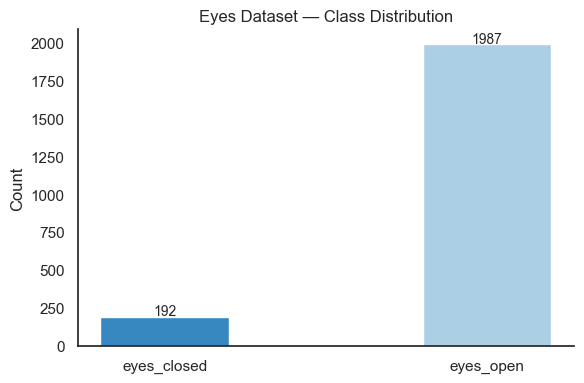

In [8]:
sns.set_theme(style="white", palette="Blues_r")
counts = [len(by_class[c]) for c in classes]
palette = sns.color_palette("Blues_r", len(classes))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(classes, counts, color=palette, width=0.4)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt + 10, str(cnt), ha="center", fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Eyes Dataset — Class Distribution")
plt.tight_layout()
sns.despine()
plt.show()

## Top 10 Images per Class (highest confidence)

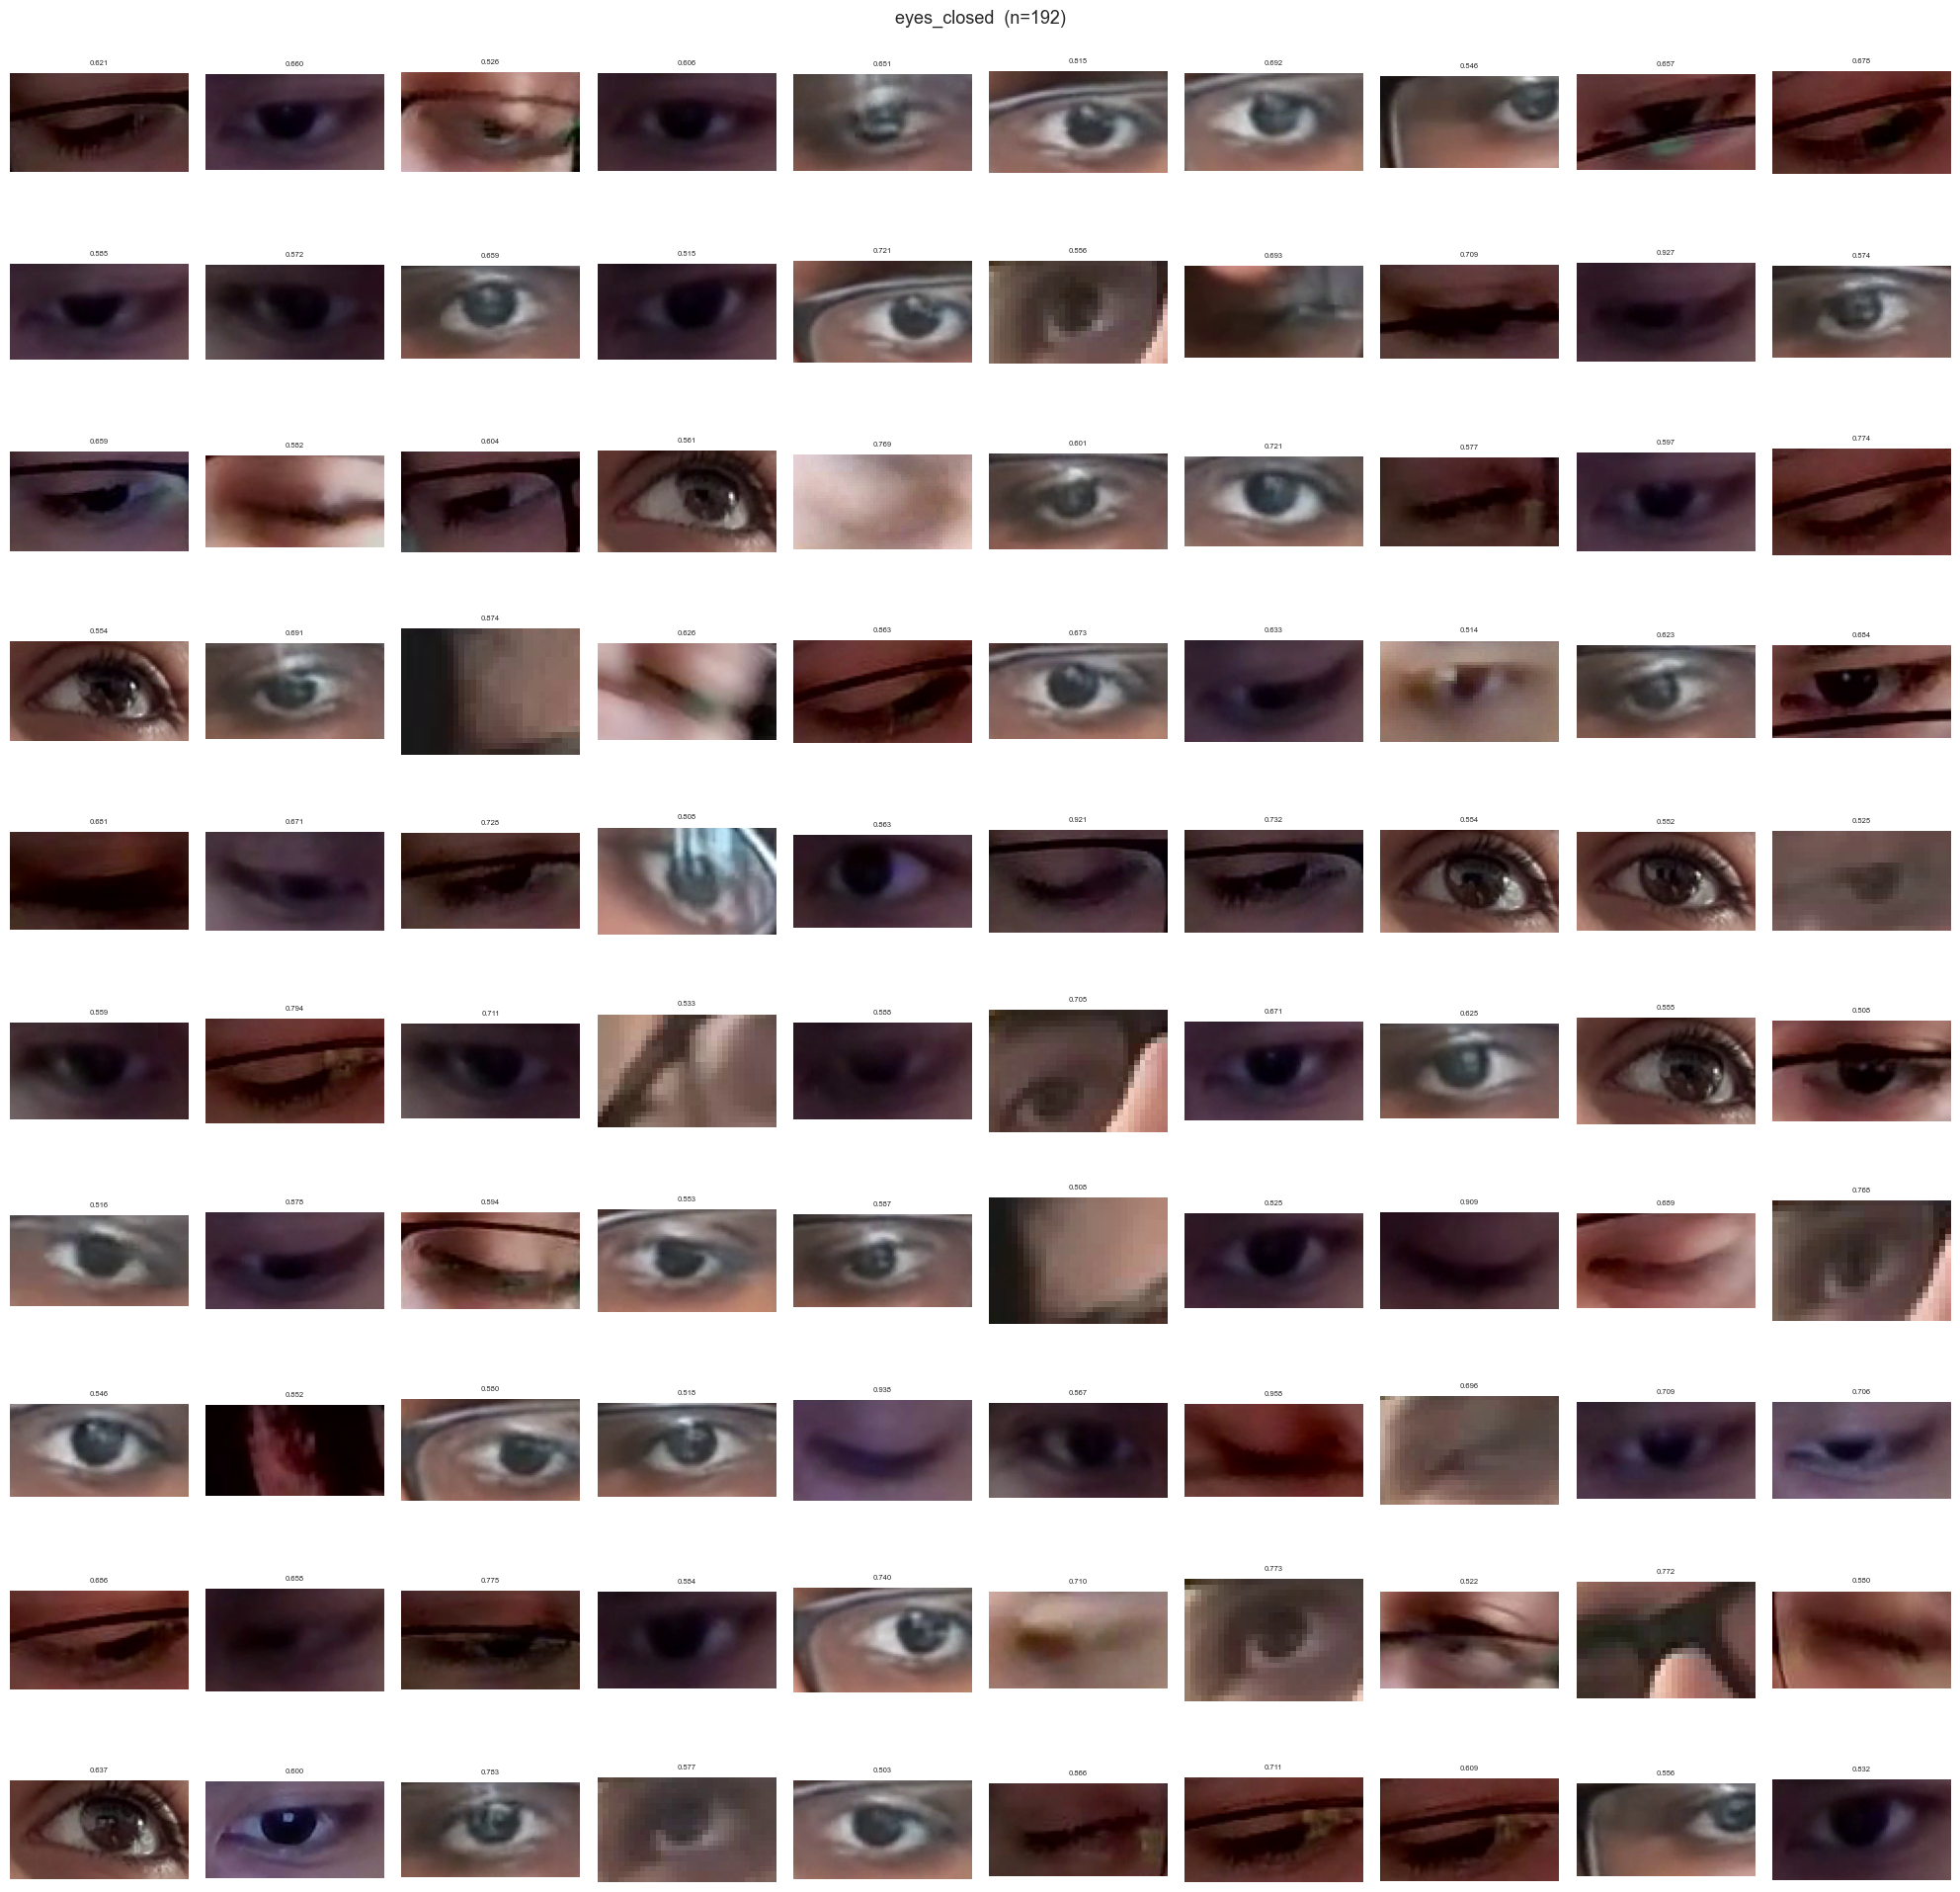

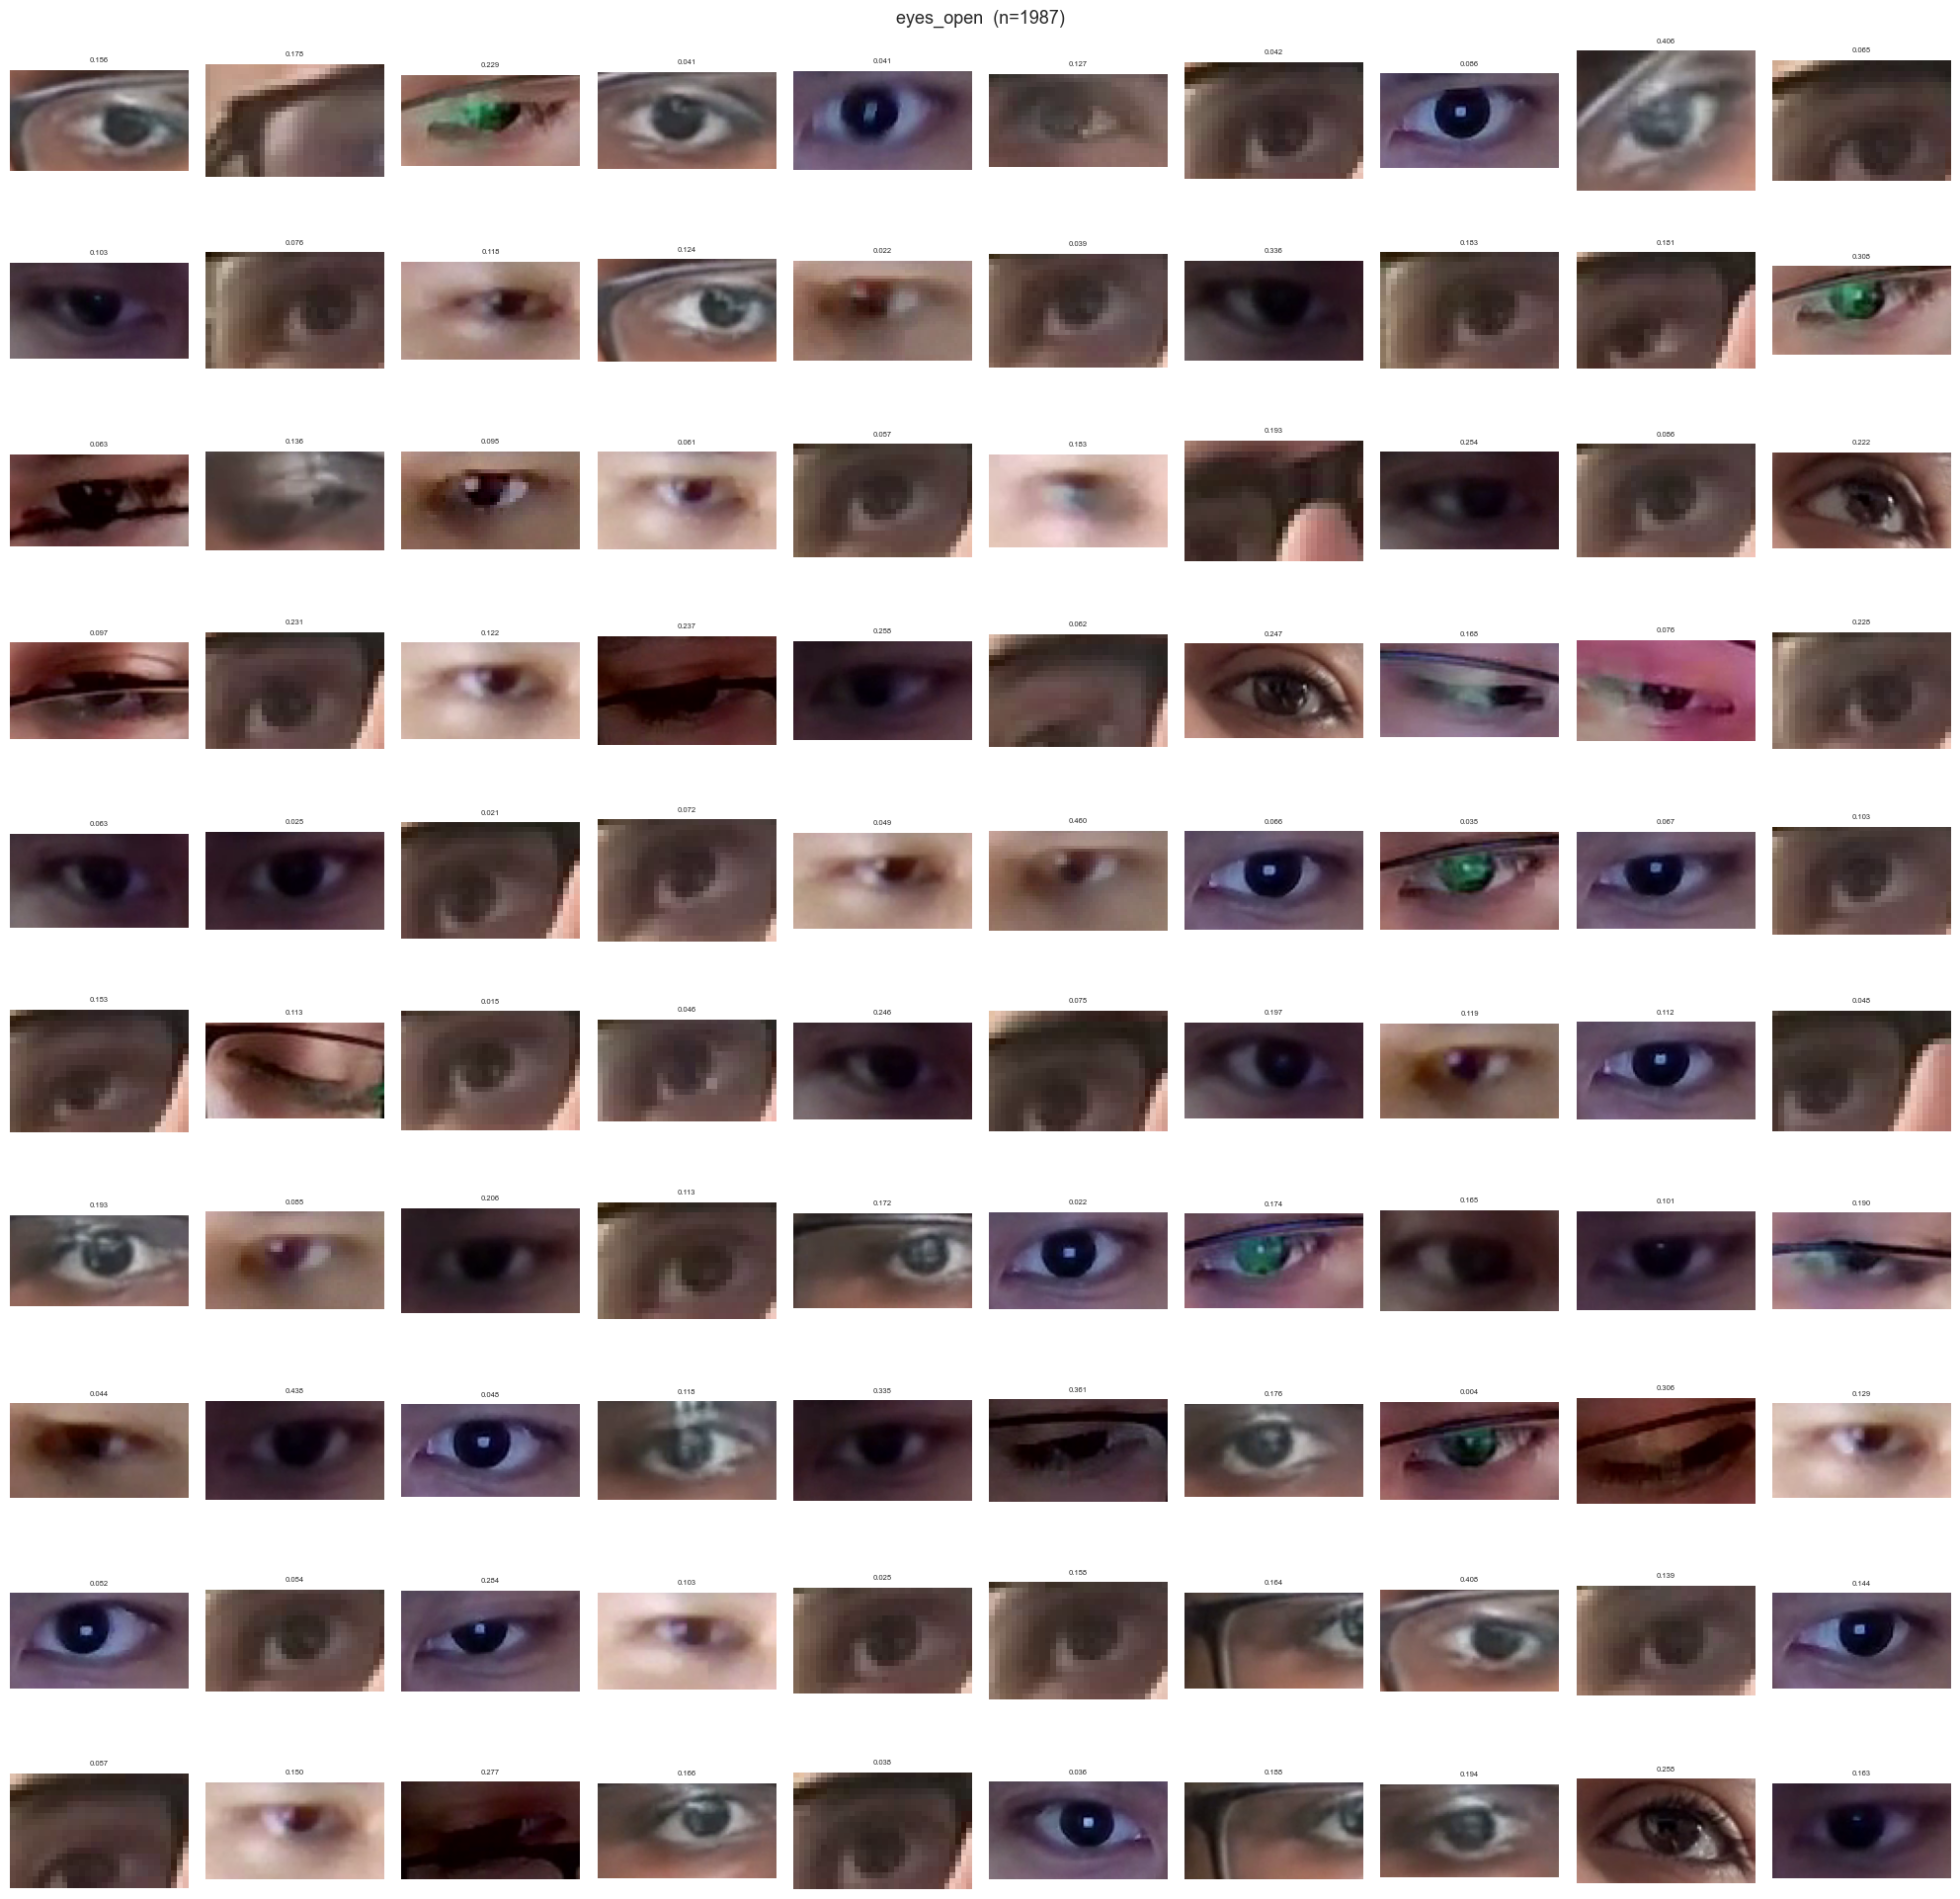

In [9]:
import random

for cls in classes:
    samples = by_class[cls]
    top = random.sample(samples, min(100, len(samples)))

    fig, axes = plt.subplots(10, 10, figsize=(20, 20))
    fig.suptitle(f"{cls}  (n={len(samples)})", fontsize=13)

    for ax, rec in zip(axes.flat, top):
        img_path = IMAGES_DIR / f"{rec['stem']}.png"
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{rec['p_pos']:.3f}", fontsize=5.5)
        ax.axis("off")

    plt.tight_layout()
    plt.show()